# **Mission 3 - Exploratory Data Analysis (EDA) with the Sales Dataset using Pandas and d Matplotlib/Seaborn**

### **Objective:**

The goal of this assignment is to help you apply your knowledge of Python for basic operations, Pandas for data manipulation, and Matplotlib/Seaborn for visualizations. You'll be working with a real-world dataset, and your tasks will include loading the data, performing EDA, and visualising the results.

###  **Dataset**

The dataset represents transaction data from a retail business, specifically sales data for products sold in various stores. It contains multiple tables that provide insights into sales, invoices, and products. Let’s break down the tables and what they represent:

#### Sales Table:

InvoiceNo: The unique identifier for each invoice (or transaction).

StockCode: A unique identifier for each product.

Quantity: The number of units sold in each transaction.

UnitPrice: The price per unit of the product.

InvoiceDate: The date when the transaction occurred.

#### Invoice Table:

InvoiceNo: The same unique identifier for each invoice, linking the sales data with the invoice details.

Country: The country where the sale was made.

#### Product Table:

StockCode: A unique identifier for each product.

Description: The name or description of the product.

Product_Category: The category the product belongs to (e.g., "Gift", "Sign", "Mug").



You will need to merge them and perform the following tasks step by step.


### Task 1: Load the Excel File
#### Objective: Import the data from the provided Excel file into Python using Pandas.

Instructions:

1. Upload the provided excel file into Fabric environment
2. Read each sheet of the excel file as a separate dataframe. 
3. Name the dataframe for sales as df_sales, the dataframe for invoice as df_invoice and the dataframe for product as df_product
4. Display the first few rows of each DataFrame to understand its structure.



In [2]:
### Code Task Here
import pandas as pd

file_path = "/lakehouse/default/Files/Online Sales Retailer.xlsx"

excel_file = pd.ExcelFile(file_path)
print(excel_file.sheet_names)

df_sales = pd.read_excel(file_path, sheet_name="Sales")
df_invoice = pd.read_excel(file_path, sheet_name="Invoice")
df_product = pd.read_excel(file_path, sheet_name="Product")
print("Sales DataFrame:")
display(df_sales.head())
print("Invoice DataFrame:")
display(df_invoice.head())
print("Product DataFrame:")
display(df_product.head())

['Sales', 'Invoice', 'Product', 'December_Sales']
Sales DataFrame:


Invoice DataFrame:


Product DataFrame:


### Task 2: Basic Python and Pandas Operations
#### Objective: Perform basic Python and Pandas operations to manipulate the data.

<mark>Instructions:</mark>

1. Create the Sales Column (Quantity * Unit Price) 

2. Check for missing values in the Sales DataFrame.

3. Replace any NaN values in the Sales and UnitPrice columns with 0.

4. Calculate basic descriptive statistics for the Quantity and UnitPrice columns (mean, median, mode, standard deviation).

In [3]:
## Code Task 2 here
df_sales["Sales"] = df_sales["Quantity"] * df_sales["UnitPrice"]
display(df_sales.head())
print(df_sales.isnull().sum())
df_sales["Sales"] = df_sales["Sales"].fillna(0)
df_sales["UnitPrice"] = df_sales["UnitPrice"].fillna(0)
print(df_sales[["Sales", "UnitPrice"]].isnull().sum())
print("Quantity Statistics:")
print("Mean:", df_sales["Quantity"].mean())
print("Median:", df_sales["Quantity"].median())
print("Mode:", df_sales["Quantity"].mode()[0])
print("Standard Deviation:", df_sales["Quantity"].std())
print("\nUnitPrice Statistics:")
print("Mean:", df_sales["UnitPrice"].mean())
print("Median:", df_sales["UnitPrice"].median())
print("Mode:", df_sales["UnitPrice"].mode()[0])
print("Standard Deviation:", df_sales["UnitPrice"].std())

InvoiceNo      0
StockCode      0
Quantity       0
UnitPrice      0
InvoiceDate    0
Sales          0
dtype: int64
Sales        0
UnitPrice    0
dtype: int64
Quantity Statistics:
Mean: 13.610961009642518
Median: 6.0
Mode: 1
Standard Deviation: 261.57756533207146

UnitPrice Statistics:
Mean: 3.0835027678710816
Median: 1.95
Mode: 1.25
Standard Deviation: 5.177652565375899


### Task 3: Merging DataFrames
#### Objective: Merge the Sales, Invoice, and Product tables based on common keys to perform a comprehensive analysis.

Instructions:

1. Merge the Sales DataFrame with the Invoice DataFrame on InvoiceNo.

2. Merge the result with the Product DataFrame on StockCode

In [9]:
## Code Task 3 here
df_merged = pd.merge(df_sales, df_invoice, on="InvoiceNo")
display(df_merged.head())
df_merged = pd.merge(df_merged, df_product, on="StockCode")
display(df_merged.head())

## Task 4: Exploratory Data Analysis (EDA)
### Objective: Conduct EDA by analysing the data, identifying patterns, trends, and outliers.

Instructions:

Use describe() to calculate summary statistics for numeric columns.

Perform basic filtering, such as filtering out sales with Quantity equal to 0.

Check for outliers in the Sales column by using a scatter plot.

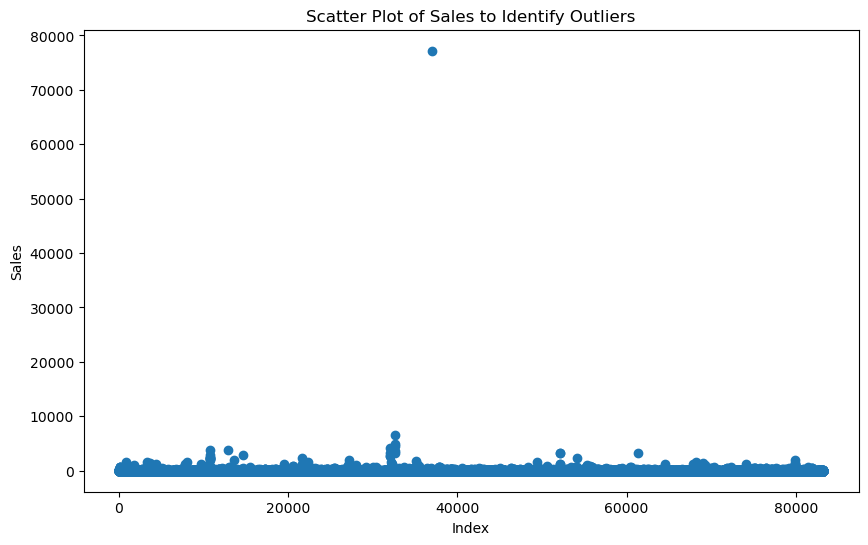

In [12]:
## Code Task 4 here
display(df_merged.describe())
df_filtered = df_merged[df_merged["Quantity"] != 0]
display(df_filtered.head())
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(df_filtered.index, df_filtered["Sales"])
plt.xlabel("Index")
plt.ylabel("Sales")
plt.title("Scatter Plot of Sales to Identify Outliers")

plt.show()

## Task 5: Data Visualisation – Scatter Plot, Histogram, and Line Chart
### Objective: Create scatter plots, histograms, and line charts to better understand the data.

Instructions:

Use a scatter plot to examine the relationship between Quantity and Sales.

Use a histogram to visualise the distribution of the Sales column.

Use a line chart to show the trend of Sales over time.

Write 1–2 sentences explaining the insights from each visualisation.

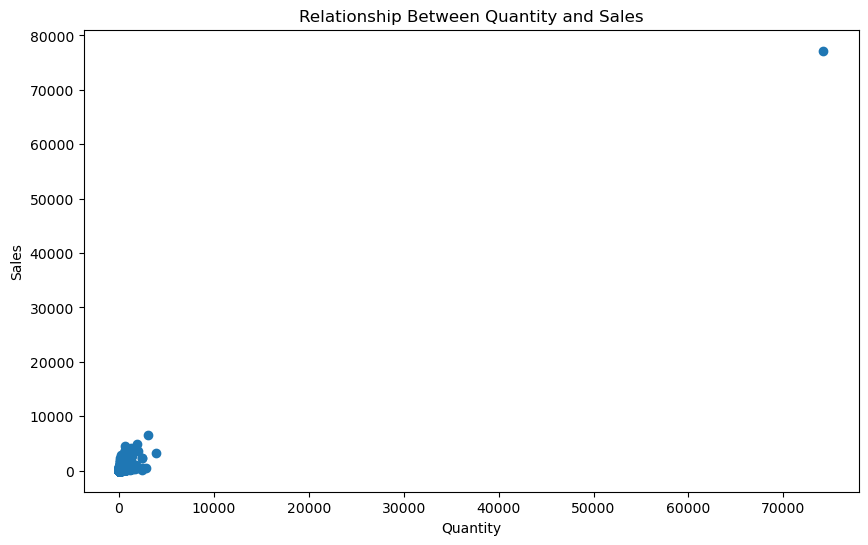

In [15]:
## Code Task 5 here
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(df_filtered["Quantity"], df_filtered["Sales"])

plt.xlabel("Quantity")
plt.ylabel("Sales")
plt.title("Relationship Between Quantity and Sales")

plt.show()


Insight: Sales usually increase when more items are sold. There is one very large sale that is much higher than the rest.

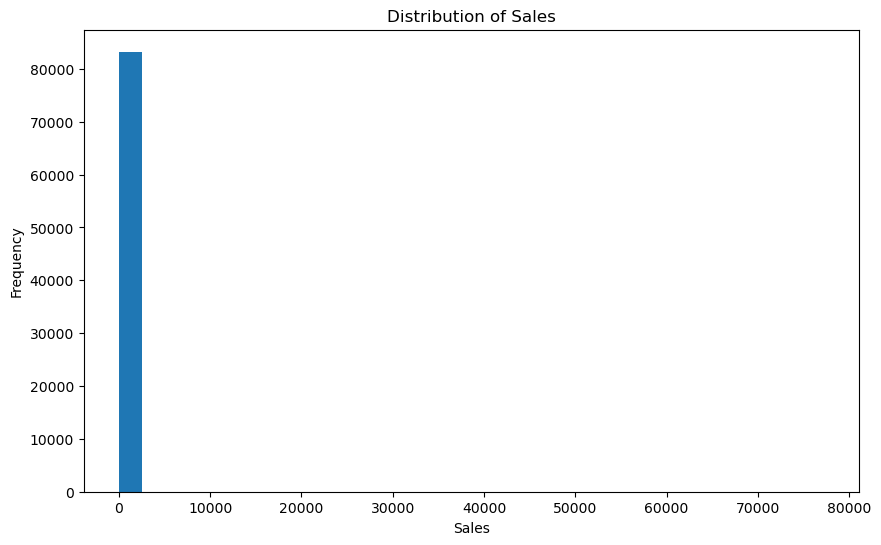

In [16]:
plt.figure(figsize=(10, 6))
plt.hist(df_filtered["Sales"], bins=30)
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.title("Distribution of Sales")
plt.show()

Insight: Most sales are low and grouped together. A few very high sales make the data spread out.

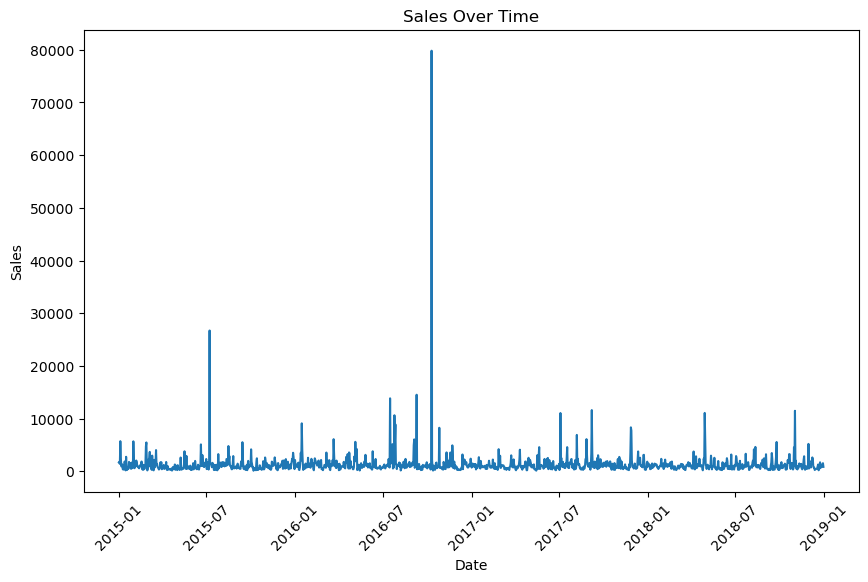

In [17]:
sales_over_time = df_filtered.groupby("InvoiceDate")["Sales"].sum()
plt.figure(figsize=(10, 6))
plt.plot(sales_over_time.index, sales_over_time.values)

plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Sales Over Time")
plt.xticks(rotation=45)

plt.show()

Insight: Sales are mostly steady over time but there are some large increases. One period has a much higher sales value than the rest.

## Task 6: Correlation and Data Insights
### Objective: Identify the relationship between different numerical columns in the dataset.

Instructions:

Calculate the correlation between Quantity and Sales.

Visualise the correlation matrix using a heatmap.

Write 1–2 sentences explaining the insights from the visualisation.

Correlation between Quantity and Sales: 0.9786092498011646
           Quantity  UnitPrice     Sales
Quantity   1.000000  -0.013917  0.978609
UnitPrice -0.013917   1.000000  0.027060
Sales      0.978609   0.027060  1.000000


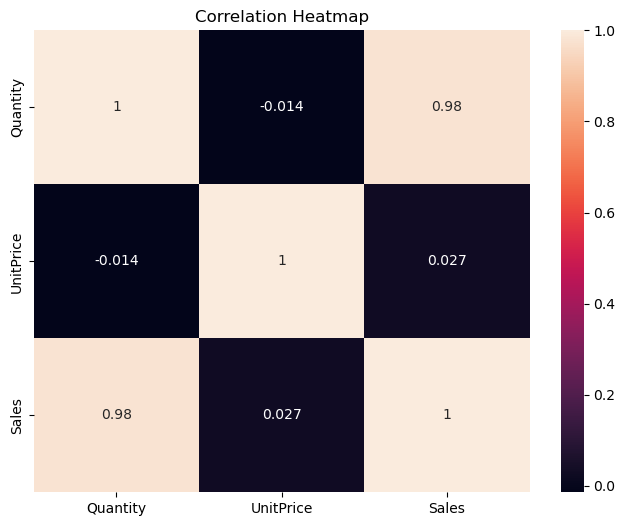

In [19]:
## Code Task 6 here
correlation = df_filtered["Quantity"].corr(df_filtered["Sales"])

print("Correlation between Quantity and Sales:", correlation)
correlation_matrix = df_filtered[["Quantity", "UnitPrice", "Sales"]].corr()
print(correlation_matrix)
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True)

plt.title("Correlation Heatmap")
plt.show()

Insight: Quantity and Sales have a strong relationship which means sales increase when more items are sold. Unit Price has very little relationship with Sales.

## Task 7: Grouping and Aggregating
### Objective: Perform grouping and aggregation operations to summarise the data.

Instructions:

GroupBy operation: Group by Product_Category and calculate the total Sales per category.

Create a Pivot Table to show Sales by Country and Product_Category.

In [21]:
## Code Task 7 here
sales_by_category = df_filtered.groupby("Product_Category")["Sales"].sum()
display(sales_by_category)
pivot_table = pd.pivot_table(
    df_filtered,
    values="Sales",
    index="Country",
    columns="Product_Category",
    aggfunc="sum",
    fill_value=0
)
display(pivot_table)

## Submission Guidelines:
Submit the Python notebook with all the tasks and visualisations.

Ensure that each task is clearly explained and that all steps are followed.

Include markdown explanations where necessary to explain your thought process.